В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [3]:
import pandas as pd
medical_df = pd.read_csv("/Users/myroslavazuieva/Desktop/ML/medical-charges.csv") # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

Метод МНК

In [19]:
import numpy as np

X = non_smoker_df['age'].values
y = non_smoker_df['charges'].values

X_b = np.c_[np.ones(len(X)), X]

In [20]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

m_mnk, b_mnk = theta_best[1], theta_best[0]
predictions_mnk = m_mnk * X + b_mnk

Full-Batch градієнтного спуску з `numpy` 

In [6]:
def full_batch_gradient_descent(X, y, lr=0.01, epochs=1000):
    m, b = 0.0, 0.0
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(np.sqrt(np.mean(error**2)))
        m_gradient = (2/n) * np.dot(error, X)
        b_gradient = (2/n) * np.sum(error)
        m -= lr * m_gradient
        b -= lr * b_gradient
    return m, b, errors

In [7]:
results = {}
for lr in [0.01, 0.001, 0.0001]:
    m_gd, b_gd, errors = full_batch_gradient_descent(X, y, lr, 1000)
    predictions = m_gd * X + b_gd
    rmse = np.sqrt(np.mean((predictions - y) ** 2))
    results[lr] = (m_gd, b_gd, errors, predictions, rmse)

/var/folders/h3/tf51715d0x9b9w1bsvw3gfr00000gn/T/ipykernel_13014/1209593979.py:8: RuntimeWarning: overflow encountered in square
  errors.append(np.sqrt(np.mean(error**2)))
/opt/anaconda3/envs/py312/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/h3/tf51715d0x9b9w1bsvw3gfr00000gn/T/ipykernel_13014/1209593979.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  m -= lr * m_gradient


In [8]:
X_raw = non_smoker_df["age"].values
y_raw = non_smoker_df["charges"].values

X_mean, X_std = X_raw.mean(), X_raw.std()
X = (X_raw - X_mean) / X_std

def full_batch_gradient_descent(X, y, lr=0.01, epochs=1000):
    m, b = 0.0, 0.0
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(np.sqrt(np.mean(error**2)))
        m_gradient = (2/n) * np.dot(error, X)
        b_gradient = (2/n) * np.sum(error)
        m -= lr * m_gradient
        b -= lr * b_gradient
    return m, b, errors

results = {}
for lr in [0.01, 0.001, 0.0001]:
    m_gd, b_gd, errors = full_batch_gradient_descent(X, y_raw, lr, 1000)
    predictions = m_gd * X + b_gd
    rmse = np.sqrt(np.mean((predictions - y_raw) ** 2))
    results[lr] = (m_gd, b_gd, errors, predictions, rmse)

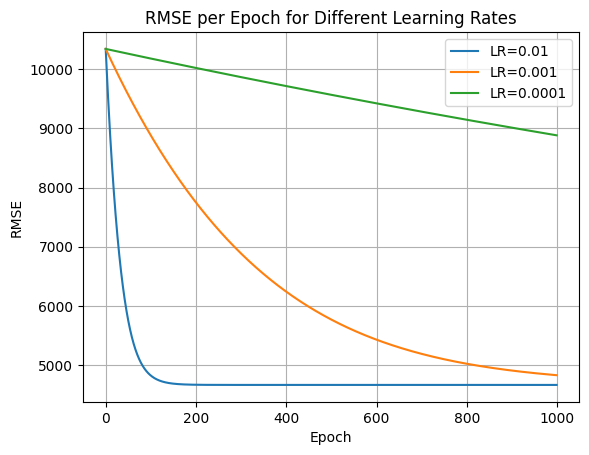

In [9]:
import matplotlib.pyplot as plt

for lr, (m, b, errors, _, _) in results.items():
    plt.plot(errors, label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('RMSE per Epoch for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

З scikit-learn.LinearRegression

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_sk = X.reshape(-1, 1)
model = LinearRegression()
model.fit(X_sk, y)

m_sklearn = model.coef_[0]
b_sklearn = model.intercept_
predictions_sklearn = model.predict(X_sk)
rmse_sklearn = np.sqrt(mean_squared_error(y, predictions_sklearn))

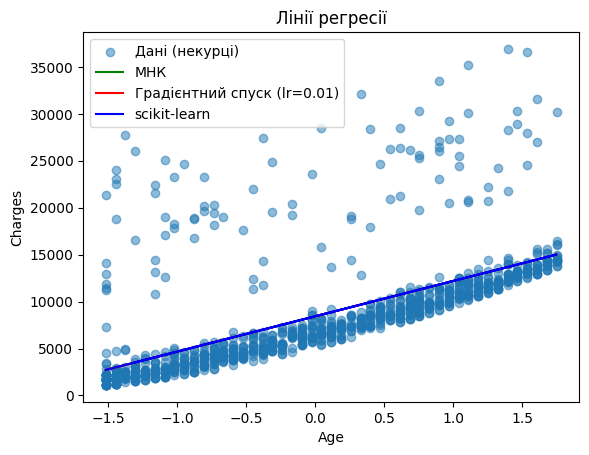

In [11]:
import matplotlib.pyplot as plt

plt.scatter(X, y, label='Дані (некурці)', alpha=0.5)
plt.plot(X, predictions_mnk, label='МНК', color='green')
plt.plot(X, results[0.01][3], label='Градієнтний спуск (lr=0.01)', color='red')
plt.plot(X, predictions_sklearn, label='scikit-learn', color='blue')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.title('Лінії регресії')
plt.show()

Результати моделей градієнтного спуску та scikit-learn майже не відрізняються — RMSE та параметри дуже близькі. Знайдені коефіцієнти відповідають логічним припущенням: з віком витрати зростають.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [13]:
# Фільтруємо лише курців
smoker_df = medical_df[medical_df["smoker"] == "yes"]

# Вхідні змінні
X_smoker = smoker_df["age"].values.reshape(-1, 1)  # 2D array
y_smoker = smoker_df["charges"].values

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Навчаємо модель
model_smoker = LinearRegression().fit(X_smoker, y_smoker)

# Прогнози
predictions_smoker = model_smoker.predict(X_smoker)

# Точність (RMSE та R²)
rmse_smoker = mean_squared_error(y_smoker, predictions_smoker, squared=False)
r2_smoker = r2_score(y_smoker, predictions_smoker)

# Коефіцієнти
m_smoker = model_smoker.coef_[0]
b_smoker = model_smoker.intercept_

/opt/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


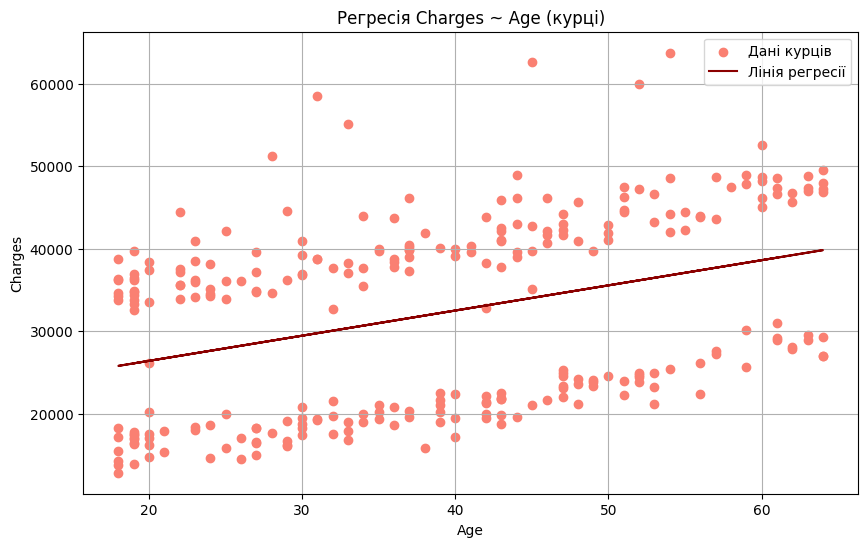

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(X_smoker, y_smoker, color='salmon', label='Дані курців')
plt.plot(X_smoker, predictions_smoker, color='darkred', label='Лінія регресії')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Регресія Charges ~ Age (курці)")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print(f"Коефіцієнт нахилу (m): {m_smoker:.2f}")
print(f"Вільний член (b): {b_smoker:.2f}")
print(f"RMSE: {rmse_smoker:.2f}")
print(f"R²: {r2_smoker:.2f}")

Коефіцієнт нахилу (m): 305.24
Вільний член (b): 20294.13
RMSE: 10711.00
R²: 0.14


Я вважаю, що ця модель має невисоку точність:
	•	R² = 0.14 — лише 14% варіації витрат пояснюється віком.
	•	RMSE ≈ 10 711 — середня похибка досить велика.
	•	Хоча вікова тенденція є (m ≈ 305), вона слабка, а розкид точок — значний.

👉 Висновок: модель не є надійною для прогнозування витрат тільки за віком. У реальному бізнесі я б її не використовував без додаткових ознак (наприклад, ІМТ, стать, дохід тощо).